# Escenario de secado al sol en lazo abierto (línea base mínima)

Semana 5 - "Modelo base validado".

Usa `escenario_sol_abierto.py`: modelo Newton calibrado con las
condiciones generales de un estudio real de secado de café en patio de
concreto (T=26.3°C, HR=63.3%, 117.5 h totales). Ver
`data/reference/eliseu_2008_secado_patio.md` para el detalle de la
fuente y la limitación explícita de esta calibración (2 puntos, no un
reajuste completo — no se pudo verificar la tabla de parámetros
original del modelo Page reportado por los autores).

In [1]:
import sys
sys.path.append(".")

import numpy as np
import matplotlib.pyplot as plt

from escenario_sol_abierto import (
    mr_sol_abierto, K_SOL_ABIERTO, TIEMPO_TOTAL_SECADO_H,
    T_AMBIENTE_MEDIA_C, HR_AMBIENTE_MEDIA_PCT,
)
from linea_base_activa import mr_linea_base_activa, TIEMPO_MAXIMO_AJUSTE_H
from modelo_secado import curva_secado

## Curva de la línea base mínima (0 a ~5 días)

k calibrado: 0.02550 1/h
Condiciones de referencia: T=26.3 C, HR=63.3 %


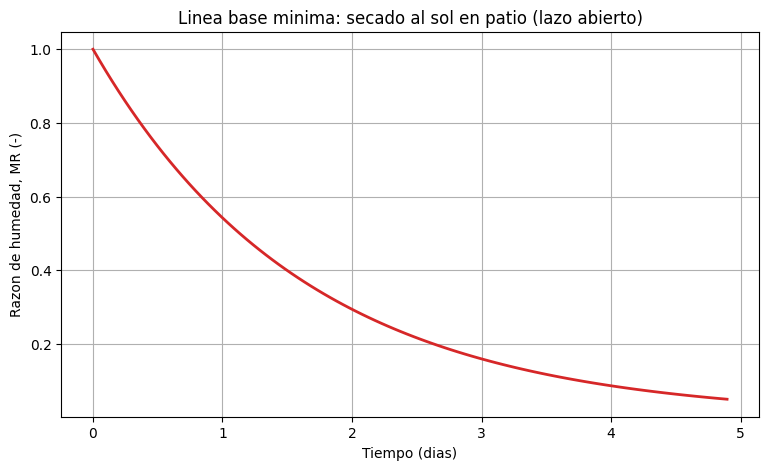

In [2]:
t_dias = np.linspace(0, TIEMPO_TOTAL_SECADO_H, 100)
mr_minima = mr_sol_abierto(t_dias)

print(f"k calibrado: {K_SOL_ABIERTO:.5f} 1/h")
print(f"Condiciones de referencia: T={T_AMBIENTE_MEDIA_C} C, HR={HR_AMBIENTE_MEDIA_PCT} %")

plt.figure(figsize=(9, 5))
plt.plot(t_dias / 24, mr_minima, linewidth=2, color="tab:red")
plt.xlabel("Tiempo (dias)")
plt.ylabel("Razon de humedad, MR (-)")
plt.title("Linea base minima: secado al sol en patio (lazo abierto)")
plt.grid(True)
plt.show()

## Comparación de las tres estrategias (misma ventana de tiempo)

Nótese la diferencia de orden de magnitud: la línea base mínima necesita
días, mientras la línea base activa y la propuesta supervisada (todavía
con parámetros preliminares) necesitan horas. Esta es la relación
cualitativa esperada entre las tres estrategias.

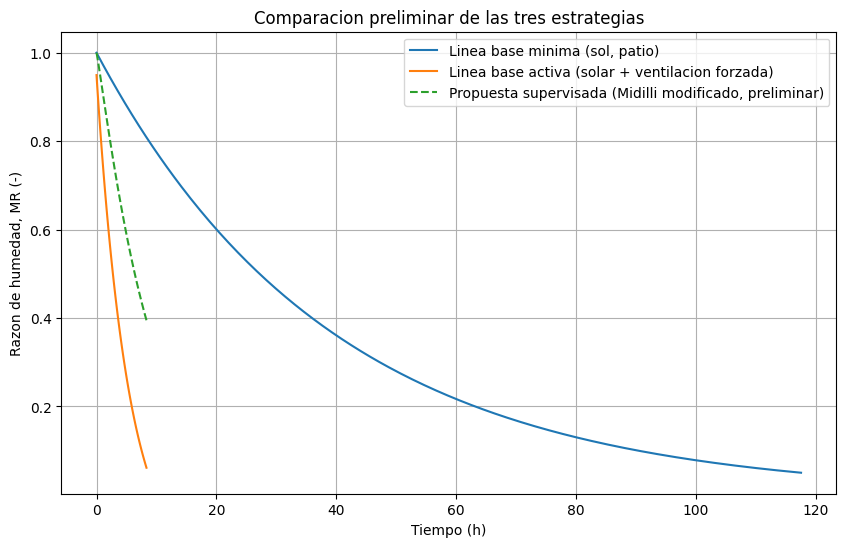

In [3]:
t_horas = np.linspace(0, TIEMPO_TOTAL_SECADO_H, 300)

curva_supervisada = curva_secado("Midilli_modificado", np.linspace(0, TIEMPO_MAXIMO_AJUSTE_H, 100))

plt.figure(figsize=(10, 6))
plt.plot(t_horas, mr_sol_abierto(t_horas), label="Linea base minima (sol, patio)")
plt.plot(np.linspace(0, TIEMPO_MAXIMO_AJUSTE_H, 100), mr_linea_base_activa(np.linspace(0, TIEMPO_MAXIMO_AJUSTE_H, 100)),
         label="Linea base activa (solar + ventilacion forzada)")
plt.plot(curva_supervisada["t"], curva_supervisada["MR"], "--",
         label="Propuesta supervisada (Midilli modificado, preliminar)")
plt.xlabel("Tiempo (h)")
plt.ylabel("Razon de humedad, MR (-)")
plt.title("Comparacion preliminar de las tres estrategias")
plt.legend()
plt.grid(True)
plt.show()

## Próximo paso (semana 5)

Con las tres estrategias esbozadas (línea mínima, línea activa,
propuesta supervisada) y el generador de ambiente listo, queda pendiente
la primera estimación de energía. La puerta física (ficha de inspección
de la secadora) queda a cargo del equipo.